# Notebook 4 — INT8 / Tensor Core decomposition thought experiment

This notebook looks at whether the high INT8 throughput of NVIDIA Tensor Cores (a class of matrix-multiply-accumulate units, `GEMM` = General Matrix Multiply) can be exploited for *exact* 36-bit modular arithmetic. The short answer is **rarely**: an exact 36-bit product needs **25 byte-level cross-products** plus recomposition and modular reduction.

**Prerequisites:** Notebooks 1–3.  
**Reading time:** about 15 minutes.

Tensor Cores are excellent at *dense low-precision matrix multiply-accumulate*. Exact RNS modular arithmetic, by contrast, requires recomposition and a modular reduction at the end of each per-limb multiplication. The mismatch is structural, not just a constant factor.

In [1]:
import math

import matplotlib.pyplot as plt
import pandas as pd
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact

from rns_arithmetic import limb_decompose, tensor_int8_model, visualization

visualization.apply_style()

## 4.1 Byte decomposition of a 36-bit integer

**Takeaway:** a 36-bit integer needs **5 bytes** ($\lceil 36/8 \rceil = 5$). One operand-pair multiplication therefore decomposes into $5 \times 5 = 25$ byte-level cross-products.

$$
a \;=\; \sum_{i=0}^{4} a_i \cdot 2^{8i}, \qquad b \;=\; \sum_{j=0}^{4} b_j \cdot 2^{8j},
$$

$$
ab \;=\; \sum_{i=0}^{4}\sum_{j=0}^{4} a_i b_j \cdot 2^{8(i+j)}.
$$

The library exposes the chunked product directly:

In [2]:
import numpy as np

rng = np.random.default_rng(seed=20260426)
a = int(rng.integers(0, 1 << 36, dtype=np.uint64))
b = int(rng.integers(0, 1 << 36, dtype=np.uint64))

a_bytes = limb_decompose.decompose_base(a, 8)
b_bytes = limb_decompose.decompose_base(b, 8)
p_bytes = limb_decompose.product_as_chunks(a, b, 8)

print(f"a       = {a}")
print(f"a bytes (LSB first) = {a_bytes}")
print(f"b       = {b}")
print(f"b bytes (LSB first) = {b_bytes}")
print(f"a*b     = {a * b}")
print(f"product as 8-bit chunks (LSB first) = {p_bytes}")
print(f"recomposed = {limb_decompose.recompose_base(p_bytes, 8)}")
print(f"match      = {limb_decompose.recompose_base(p_bytes, 8) == a * b}")

a       = 40622410582
a bytes (LSB first) = [86, 203, 72, 117, 9]
b       = 23115661151
b bytes (LSB first) = [95, 255, 204, 97, 5]
a*b     = 939013878150308699882
product as 8-bit chunks (LSB first) = [234, 30, 22, 167, 17, 115, 111, 231, 50]
recomposed = 939013878150308699882
match      = True


## 4.2 Cross-product count grows quadratically with operand size

**Takeaway:** for operand width $w$ and chunk width $c$, the cross-product count is $\lceil w/c \rceil^2$. Quadratic in $\lceil w/c \rceil$.

The interactive cell below sweeps both.

In [3]:
rows = []
for operand_bits in [36, 64, 128]:
    for chunk_bits in [4, 8, 16, 32]:
        chunks = math.ceil(operand_bits / chunk_bits)
        rows.append(
            {
                "operand_bits": operand_bits,
                "chunk_bits": chunk_bits,
                "chunks": chunks,
                "cross_products": chunks * chunks,
            }
        )
pd.DataFrame(rows)

,operand_bits,chunk_bits,chunks,cross_products
0,36,4,9,81
1,36,8,5,25
2,36,16,3,9
3,36,32,2,4
4,64,4,16,256
5,64,8,8,64
6,64,16,4,16
7,64,32,2,4
8,128,4,32,1024
9,128,8,16,256


### Interactive: cross-product count

Static default ($w = 36$, $c = 8$ — the canonical INT8 case for 36-bit RNS) shown first.

In [4]:
def show_chunk_count(operand_bits: int, chunk_bits: int) -> None:
    chunks = math.ceil(operand_bits / chunk_bits)
    K = chunks * chunks
    print(f"operand_bits = {operand_bits}")
    print(f"chunk_bits   = {chunk_bits}")
    print(f"chunks       = ceil({operand_bits}/{chunk_bits}) = {chunks}")
    print(f"K (cross-products) = {chunks}^2 = {K}")


show_chunk_count(36, 8)

operand_bits = 36
chunk_bits   = 8
chunks       = ceil(36/8) = 5
K (cross-products) = 5^2 = 25


In [5]:
interact(
    show_chunk_count,
    operand_bits=IntSlider(value=36, min=8, max=128, step=4, description="operand_bits"),
    chunk_bits=Dropdown(options=[4, 8, 16, 32], value=8, description="chunk_bits"),
);

interactive(children=(IntSlider(value=36, description='operand_bits', max=128, min=8, step=4), Dropdown(descri…

## 4.3 Tensor Core mapping idea

**Takeaway:** for matrices of residues, the byte decomposition lifts to **25 INT8 GEMMs** plus weighted recomposition plus carry handling plus modular reduction.

Decompose each matrix of residues into byte matrices,

$$
A \;=\; \sum_i A_i \cdot 2^{8i}, \qquad B \;=\; \sum_j B_j \cdot 2^{8j},
$$

and the matrix product becomes

$$
C \;=\; AB \;=\; \sum_{i,j} (A_i B_j) \cdot 2^{8(i+j)}.
$$

The grid below visualizes the byte-shift index $(i + j)$ of each cross-product. Cells on the same diagonal contribute to the same byte position of the recomposed matrix.

In [6]:
g = tensor_int8_model.byte_grid(36, 8)
df_grid = pd.DataFrame(
    g, index=[f"a_{i}" for i in range(g.shape[0])], columns=[f"b_{j}" for j in range(g.shape[1])]
)
df_grid

,b_0,b_1,b_2,b_3,b_4
a_0,0,1,2,3,4
a_1,1,2,3,4,5
a_2,2,3,4,5,6
a_3,3,4,5,6,7
a_4,4,5,6,7,8


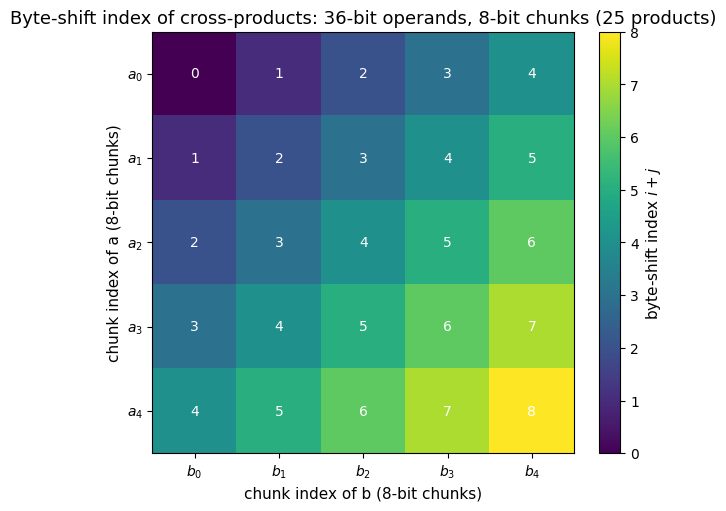

In [7]:
fig = visualization.byte_grid_heatmap(36, 8)
plt.show()

## 4.4 Why Booth is not the answer for Tensor Cores

**Takeaway:** Booth produces signed shifted copies of one operand; Tensor Cores consume dense low-precision matrix tiles. These are different computational models.

Concretely, for 36-bit random values:

- Radix-4 Booth: ~13.5 expected non-zero signed partial-product rows (Notebook 1).
- INT8 chunking: 25 dense byte-level cross-products.

Booth does *not* reduce the 5×5 byte-product grid into a small number of Tensor Core calls in any clean way. The signed-digit structure that gives Booth its advantage in a hardware multiplier has no obvious analog in dense tile-multiply hardware.

## 4.5 INT8 break-even model

**Takeaway:** INT8 chunking can pay off only if the raw INT8-vs-native throughput advantage exceeds $K \cdot O$, where $K$ is the chunk-product count (25 for 36-bit at byte chunks) and $O \geq 1$ folds in recomposition, carry handling, and modular reduction overhead.

$$
R \;>\; K \cdot O
$$

For 36-bit operands at INT8 chunks: $K = 25$, so even before recomposition overhead, you need at least a **25× raw throughput advantage** to break even. With realistic overhead the bar is higher — and this is for *coefficient-wise* RNS multiplication, the case where Tensor Cores are most plausibly applicable. Strict element-wise modular arithmetic is not naturally Tensor-Core-shaped.

In [8]:
def show_int8_breakeven(operand_bits: int, chunk_bits: int, overhead_factor: float) -> None:
    chunks = math.ceil(operand_bits / chunk_bits)
    K = chunks * chunks
    R_min = tensor_int8_model.int8_break_even(K, overhead_factor)
    print(f"operand_bits        = {operand_bits}")
    print(f"chunk_bits          = {chunk_bits}")
    print(f"K (cross-products)  = {K}")
    print(f"overhead_factor     = {overhead_factor:.2f}")
    print(f"required raw advantage R > K * O = {R_min:.2f}x")


show_int8_breakeven(36, 8, 1.0)

operand_bits        = 36
chunk_bits          = 8
K (cross-products)  = 25
overhead_factor     = 1.00
required raw advantage R > K * O = 25.00x


In [9]:
interact(
    show_int8_breakeven,
    operand_bits=IntSlider(value=36, min=8, max=128, step=4, description="operand_bits"),
    chunk_bits=Dropdown(options=[4, 8, 16, 32], value=8, description="chunk_bits"),
    overhead_factor=FloatSlider(value=1.0, min=1.0, max=4.0, step=0.1, description="O"),
);

interactive(children=(IntSlider(value=36, description='operand_bits', max=128, min=8, step=4), Dropdown(descri…

## Takeaway

- A 36-bit integer needs **5 bytes**, so an exact 36-bit multiplication is **25 byte-level cross-products** plus recomposition and modular reduction.
- For arrays / matrices of residues this lifts to **25 INT8 GEMMs**. The cross-product count grows quadratically with operand width at fixed chunk width.
- INT8 chunking can win only when the raw INT8-throughput advantage exceeds $K \cdot O$ — at minimum 25× for 36-bit operands, more in practice.
- Booth recoding does not save Tensor Cores from this: the signed-digit structure has no clean analog in dense tile-multiply hardware.
- Tensor Cores may help when a workload is dominated by very large dense matrix operations and the recomposition/reduction overhead is amortized — but ordinary coefficient-wise RNS modular multiplication is not naturally Tensor-Core-shaped.
- The right framing remains the one from Notebook 3: **choose RNS prime sizes that match native arithmetic widths** (30/31-bit primes for 64-bit CPUs); decomposition tricks are a fallback, not a shortcut.